In [ ]:
# ---------- INITIALIZE ----------
from google.colab import drive
drive.mount('/content/drive')
%cd /content/drive/MyDrive/dl4m/final-project
%load_ext autoreload
%autoreload 2

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/drive/MyDrive/dl4m/final-project


In [ ]:
# ---------- IMPORTS ----------
import utils as u

import IPython.display as ipd
import matplotlib.pyplot as plt
import os
import pandas as pd
import random
import torch
import torchaudio

In [ ]:
# ---------- DEFINE DATA PATH ----------
data_home = '/content/drive/MyDrive/dl4m/final-project/SONYC'

# ---------- LOAD ANNOTATIONS ----------
annotations_path = os.path.join(data_home, 'annotations.csv')
annotations_df = pd.read_csv(annotations_path)

# ---------- LOAD AUDIO FILES AND LABELS ----------
if os.path.exists(data_home):
    audio_dir = os.path.join(data_home, 'audio')

    if not os.path.exists(audio_dir):
        print("Extract the audio files with script (unpack_audio.sh)")

    else:
        # You must have imported your utilities module as u before this
        # Section Title (for fun)
        print("-" * 80)
        title = f"AUDIO FILES AND LABELS"
        print("\n" + title.center(80) + "\n")

        # Audio files
        audio_files, labels = u.load_data(audio_dir)
        print("-" * 80)
        print("Total number of audio files:", len(audio_files))
        print("-" * 80)
        print("\nSample audio files:")
        print("-" * 80)
        print(audio_files[:5])

        # Annotations
        print("\nSample annotations:")
        print("-" * 80)  # horizontal separator
        print(annotations_df.head())

else:
    print('Data directory not found.')

--------------------------------------------------------------------------------

                             AUDIO FILES AND LABELS                             

--------------------------------------------------------------------------------
Total number of audio files: 18528
--------------------------------------------------------------------------------

Sample audio files:
--------------------------------------------------------------------------------
['/content/drive/MyDrive/dl4m/final-project/SONYC/audio/32_013690.wav'
 '/content/drive/MyDrive/dl4m/final-project/SONYC/audio/02_002507.wav'
 '/content/drive/MyDrive/dl4m/final-project/SONYC/audio/01_002247.wav'
 '/content/drive/MyDrive/dl4m/final-project/SONYC/audio/39_007821.wav'
 '/content/drive/MyDrive/dl4m/final-project/SONYC/audio/01_008226.wav']

Sample annotations:
--------------------------------------------------------------------------------
  split  sensor_id audio_filename  annotator_id  borough  block  latitude  \
0 

Train sensors   : {1, 2, 8, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 45}
Validate sensors: {0, 3, 4, 5, 6, 7, 9, 10, 46}
Test sensors    : {0, 1, 2, 3, 4, 5, 6, 7, 9, 10, 11, 12, 13, 14, 16, 17, 18, 20, 22, 23, 24, 25, 27, 29, 30, 31, 32, 33, 34, 35, 37, 38, 39, 40, 41, 45, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 61}


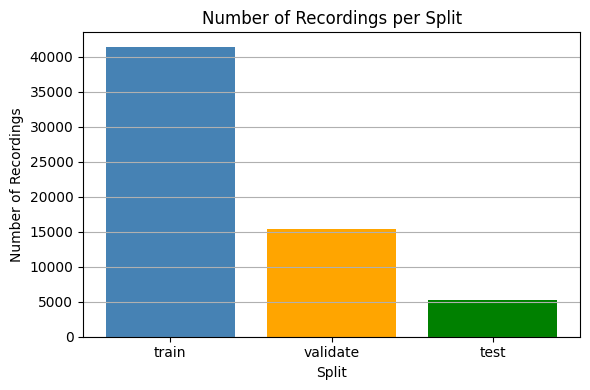

In [ ]:
# ---------- ASSIGN AND PLOT SPLIT DATA ----------

# ---------- ASSIGN SPLITS ----------
train_df = annotations_df[annotations_df['split'] == 'train']
valid_df = annotations_df[annotations_df['split'] == 'validate']  # optional, only if exists
test_df  = annotations_df[annotations_df['split'] == 'test']

# ---------- PRINT SENSOR SETS ----------
print("Train sensors   :", set(train_df['sensor_id']))
print("Validate sensors:", set(valid_df['sensor_id']))
print("Test sensors    :", set(test_df['sensor_id']))

# ---------- COUNT RECORDINGS PER SPLIT ----------
split_counts = annotations_df['split'].value_counts().reindex(
    ['train', 'validate', 'test'], fill_value=0
)

# ---------- PLOT RECORDINGS ----------
plt.figure(figsize=(6, 4))
colors = ['steelblue', 'orange', 'green']
plt.bar(split_counts.index, split_counts.values, color=colors[:len(split_counts)])

plt.title("Number of Recordings per Split")
plt.xlabel("Split")
plt.ylabel("Number of Recordings")
plt.grid(axis='y')
plt.tight_layout()
plt.show()

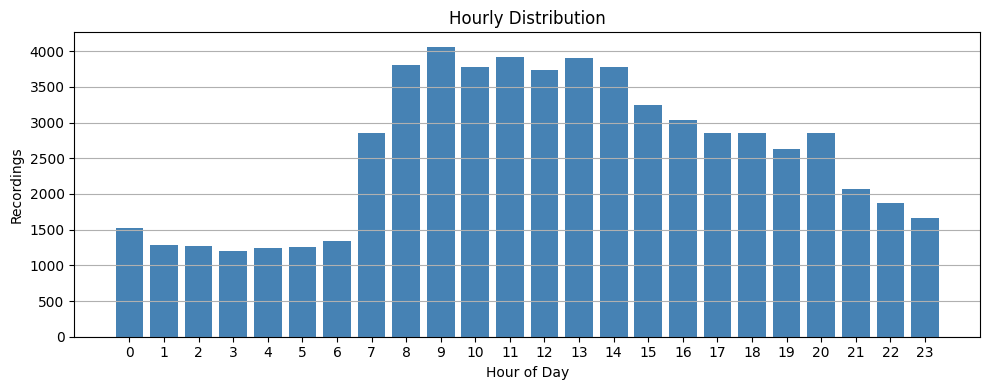

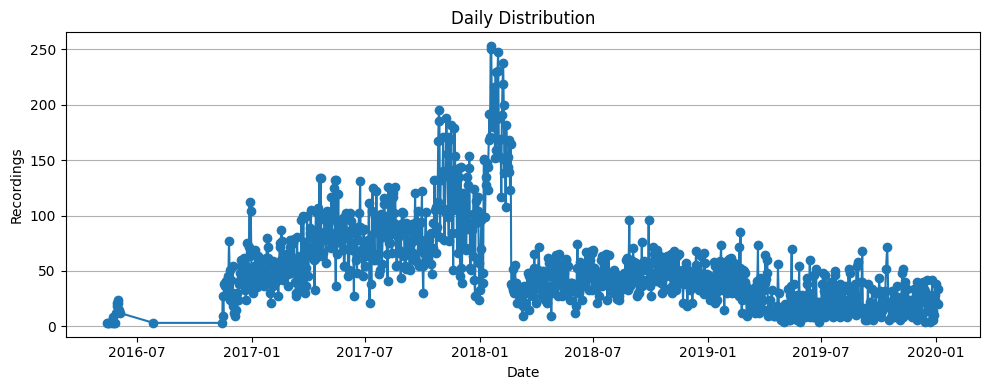

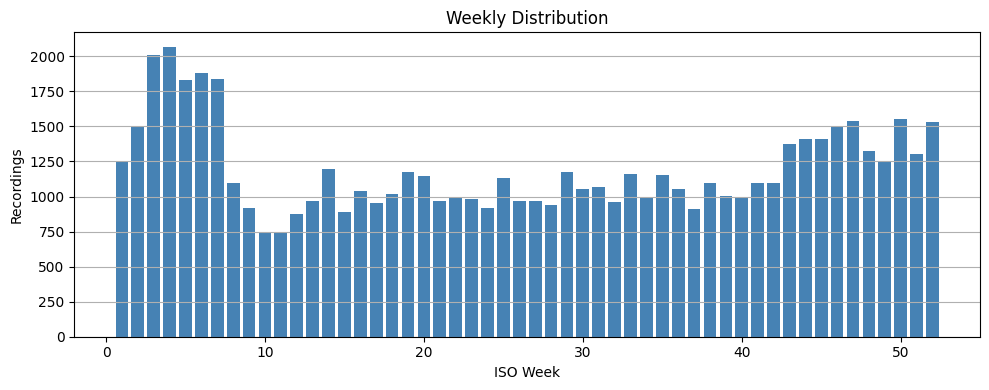

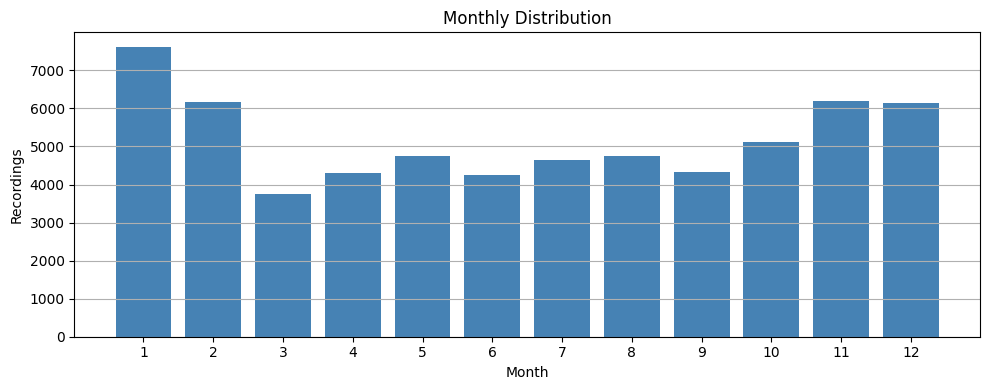

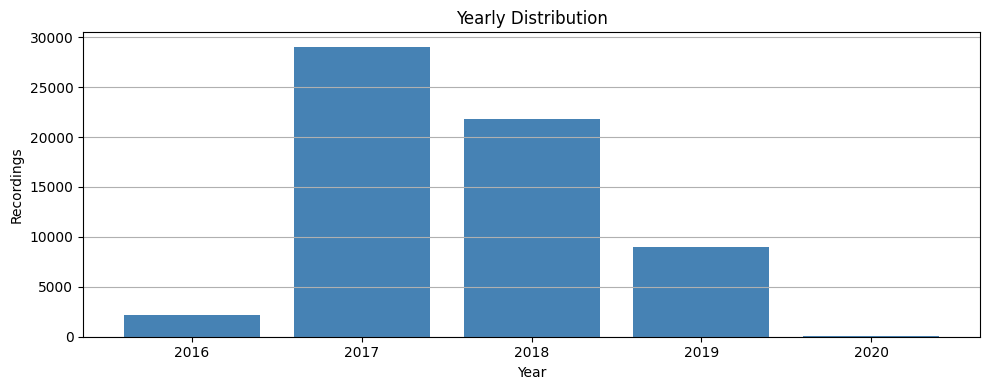

In [ ]:
# ---------- COMPUTE AND PLOT TEMPORAL DATA (FULL DATASET) ----------

# Construct datetime column
annotations_df = u.construct_datetime(annotations_df)

# Plot overall time-based distributions
u.compute_and_plot_distributions(annotations_df)

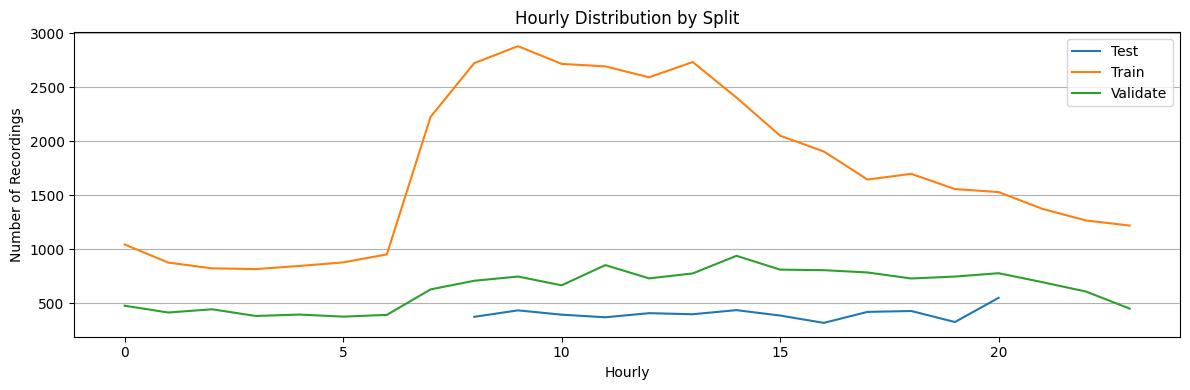

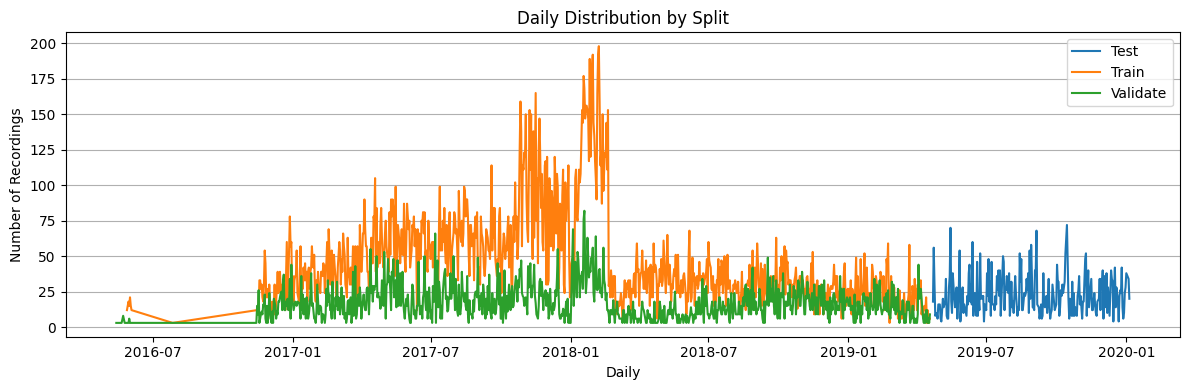

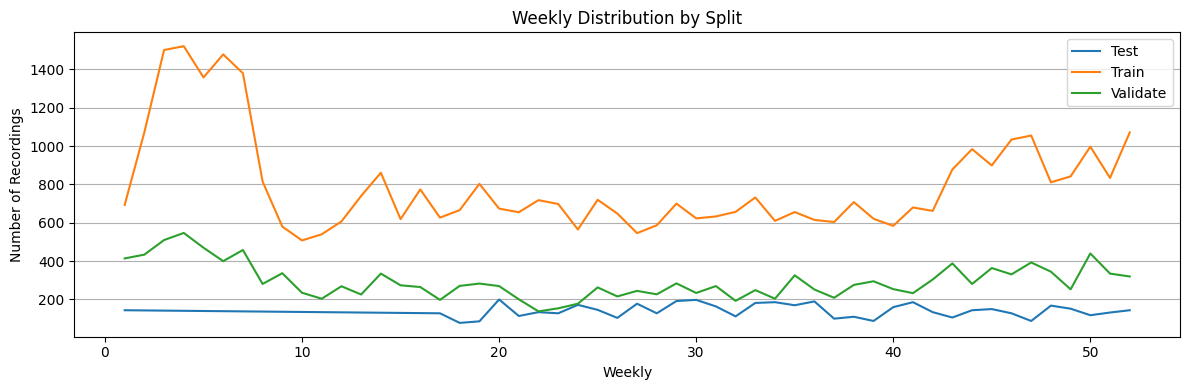

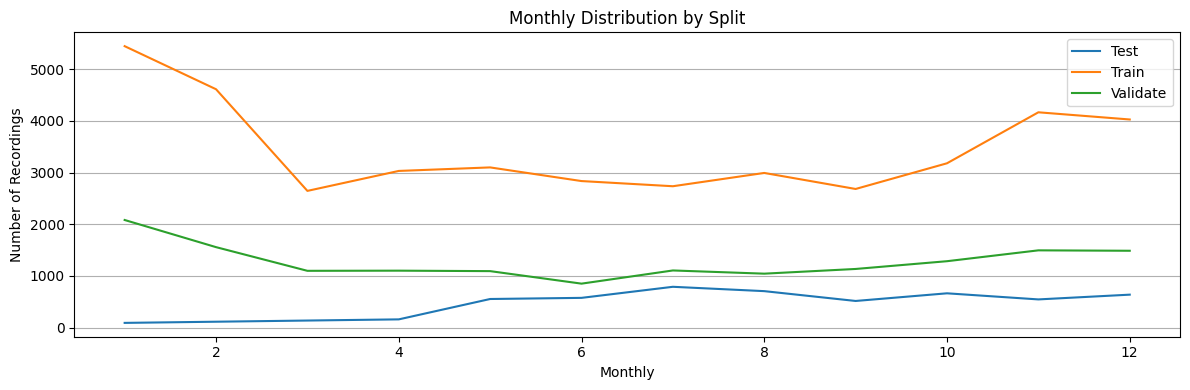

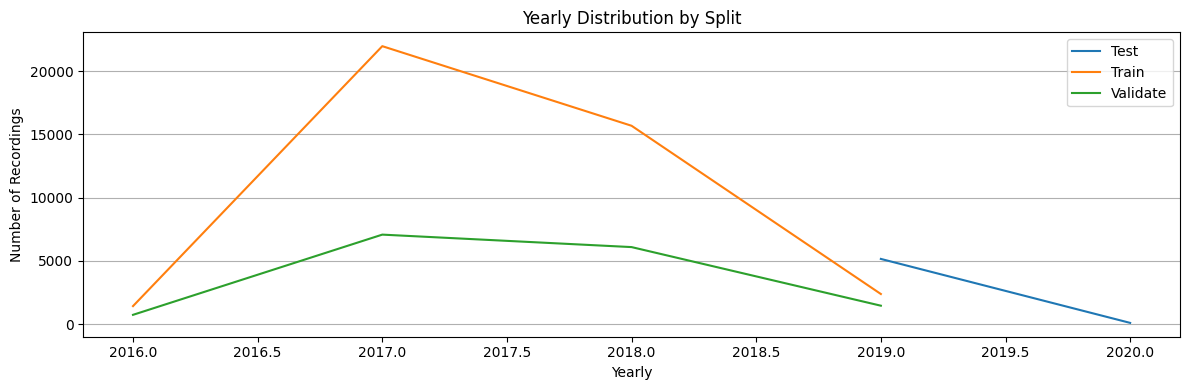

In [ ]:
# ---------- COMPUTE AND PLOT TEMPORAL DATA (SPLIT) ----------
u.plot_distributions_by_split(annotations_df)

--------------------------------------------------------------------------------

                         PLOT AND PLAYBACK AUDIO FILES                          

--------------------------------------------------------------------------------
Loaded audio file : /content/drive/MyDrive/dl4m/final-project/SONYC/audio/00_001460.wav
Waveform shape    : (1, 480000)
Sample rate       : 48000 Hz
--------------------------------------------------------------------------------


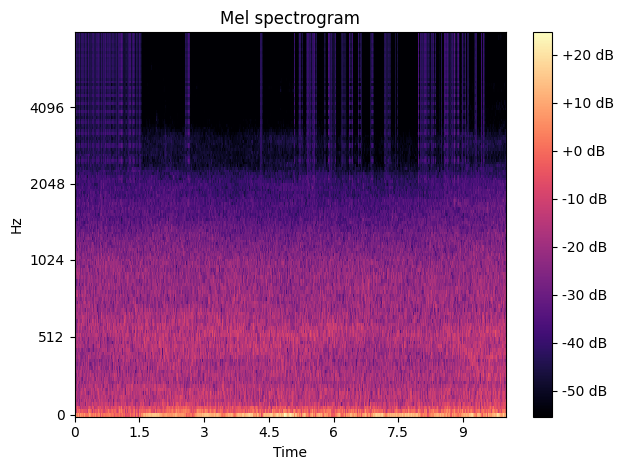

In [ ]:
# ---------- PLOT AND PLAYBACK AUDIO FILES ----------

# ---------- SELECT RANDOM FILE ----------
example_audio = random.choice(audio_files)

# ---------- LOAD AUDIO DATA ----------
waveform, sample_rate = torchaudio.load(example_audio)
waveform = waveform.numpy()

# ---------- DISPLAY FILE INFO ----------
print("-" * 80)
title = "PLOT AND PLAYBACK AUDIO FILES"
print("\n" + title.center(80) + "\n")
print("-" * 80)
print(f"Loaded audio file : {example_audio}")
print(f"Waveform shape    : {waveform.shape}")
print(f"Sample rate       : {sample_rate} Hz")
print("-" * 80)

# ---------- PLOT MEL SPECTROGRAM ----------
u.compute_mel_spectrogram(
    waveform,
    sample_rate,
    n_mels=128,
    hop_length=512
)

# ---------- PLAY AUDIO ----------
ipd.Audio(example_audio)